In [1]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *
sphere = Hypersphere(dim=2)


In [2]:
n_samples = 1000

# noise variance
sigma2 = 0.5

# prior parameters
kappa = 50
num_modes = 2
G_params = {'num_modes': num_modes, 'kappa': kappa}
# for density estimation
M = 3
rho = 1e-2

In [3]:

Theta = S2_multimodal_prior(n_samples, G_params)
X = sphere.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
delta = denoiser('S2', X, M, rho, sigma2, X)

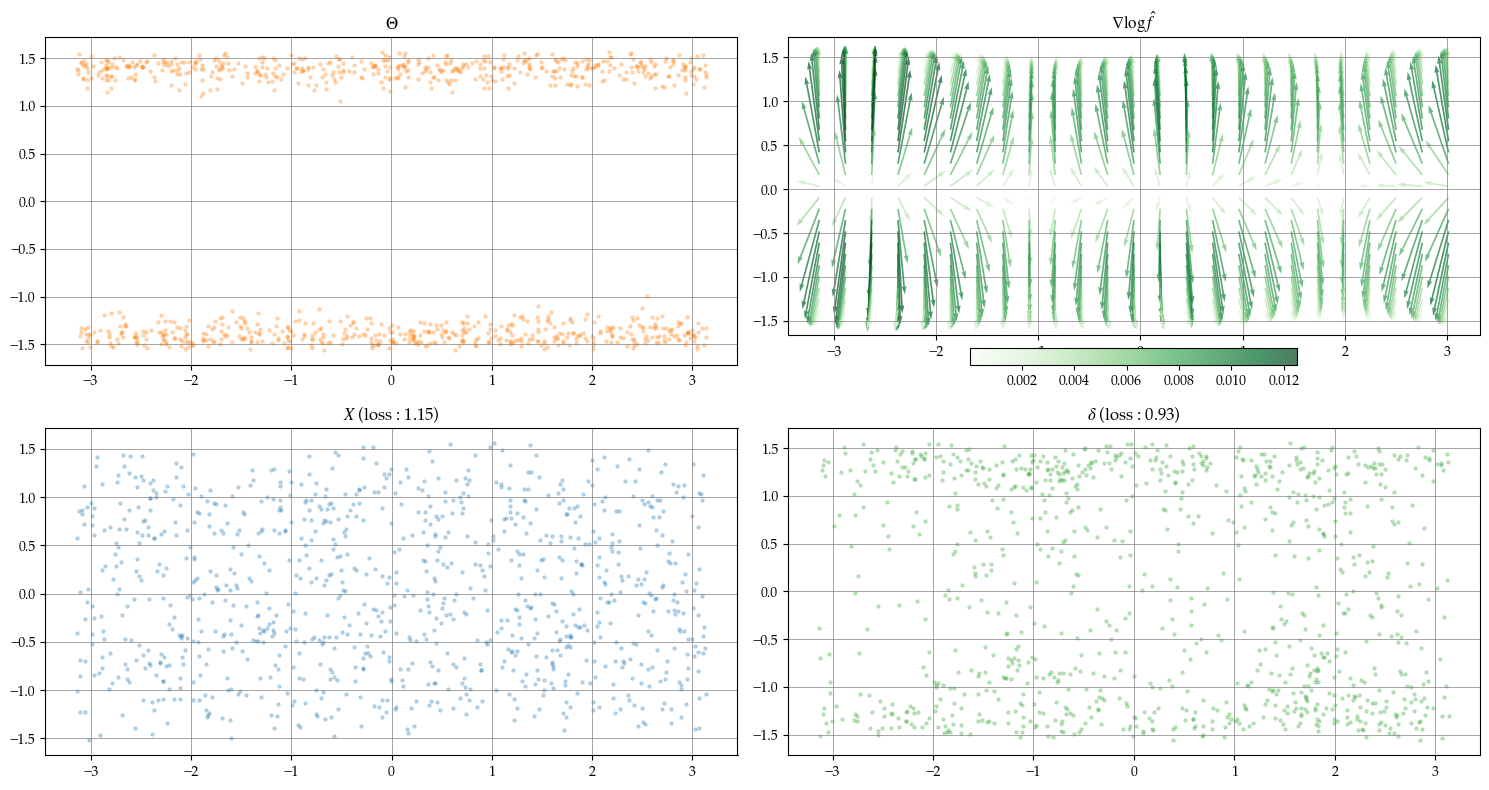

Naive Loss: 1.1523
Denoised Loss: 0.9317


In [4]:
fig, axs = plt.subplots(2, 2, figsize=(15, 8), 
                        # subplot_kw={'projection': 'mollweide'}
                        )
loss_N = (sphere.metric.dist_broadcast(X, Theta).ravel()**2).mean()
loss_T = (sphere.metric.dist_broadcast(delta, Theta).ravel()**2).mean()      
S2scatter(Theta, axs[0,0], color='C1', alpha=0.25)
axs[0,0].set_title('$\Theta$')
S2scatter(X, axs[1,0], color='C0', alpha=0.25)
axs[1,0].set_title('$X$ (loss : {:.2f})'.format(loss_N))
S2scatter(delta, axs[1,1], color='C2', alpha=0.25)
axs[1,1].set_title('$\delta$ (loss : {:.2f})'.format(loss_T))

S2plot_quiver(fig, {'X' : X, 'M' : M}, rho, 'score', axs[0,1], skip = 2, grid_resolution = 50, scale =.1)
plt.tight_layout()
plt.show()
print(f'Naive Loss: {loss_N:.4f}')
print(f'Denoised Loss: {loss_T:.4f}')

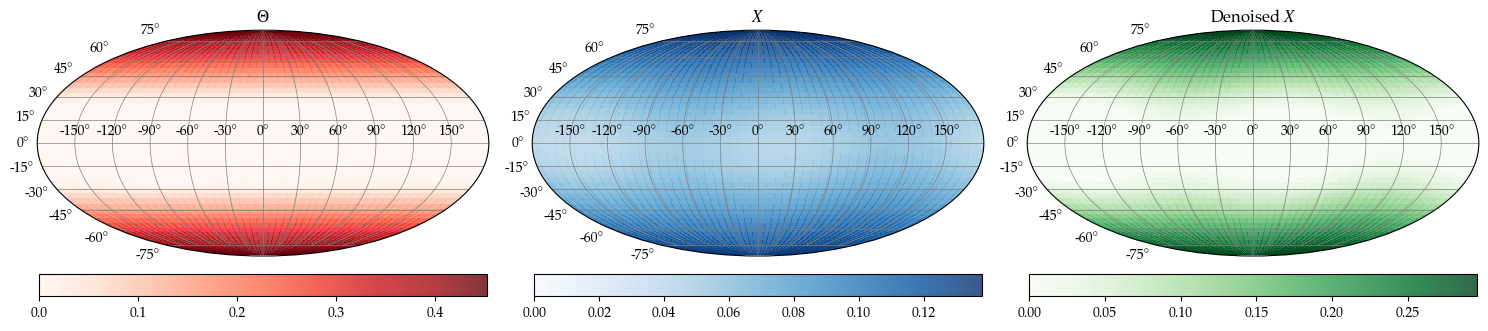

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'mollweide'})

grid_resolution = 50
grid, grid_theta, grid_phi = S2grid(grid_resolution)

densities = [density_estimate('S2', data, M, grid)[1].reshape(grid_resolution, grid_resolution) for data in [Theta, X, delta]]
vmax = None #max([d.max() for d in densities])

for hat_f, ax, title, cmap in zip(densities, axs, ['$\\Theta$', '$X$', 'Denoised $X$'], ['Reds', 'Blues', 'Greens']):
    im = ax.pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f,
                    alpha=0.8, shading='auto', cmap=cmap, vmin=0, vmax=vmax)
    fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
    ax.grid(True, color='gray', lw=0.5)
    ax.set_title(title)
plt.tight_layout(); plt.show()

# fig = S2plot_density_gradient_score(X,M,sigma2,rho, grid_resolution =50, skip=2, mollwide=True); plt.show()

   

#  Naive and Denoised Risk Ratio (MC)

modes=4, σ²=0.75: 100%|██████████| 3/3 [00:00<00:00,  4.13it/s]
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to

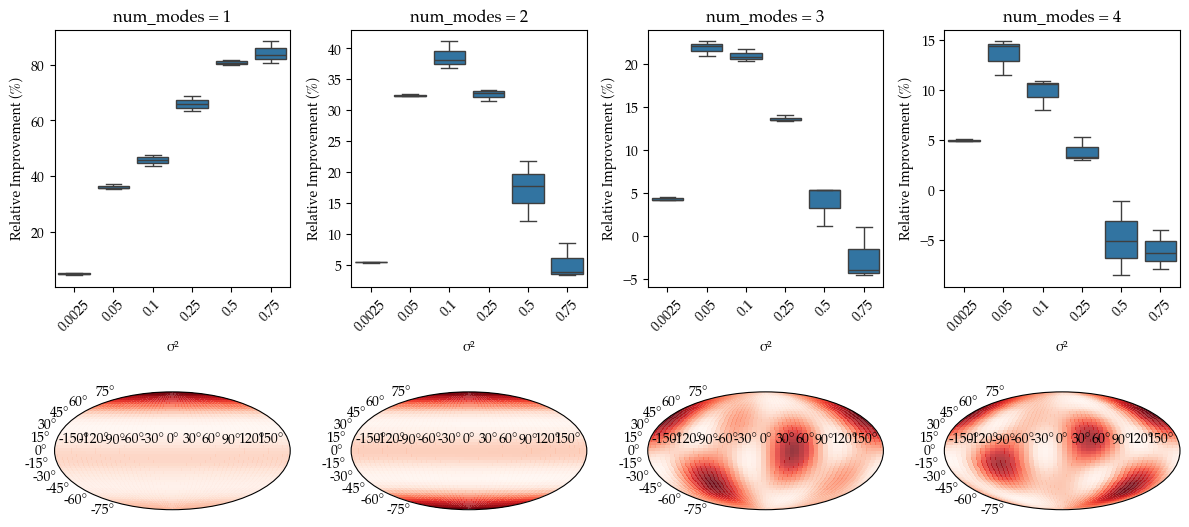

In [78]:
kappa = 50
n_samples = 1000
rho = 1e-2
M = 5
NMC = 3

all_num_modes =  [1, 2, 3, 4]
def MCrun(n, sigma2, M, rho, G_params):
    sphere = Hypersphere(2)
    Theta = S2_multimodal_prior(n_samples, G_params)
    X = sphere.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
    delta = denoiser('S2', X, M, rho, sigma2, X)
    loss_N = (sphere.metric.dist_broadcast(X, Theta)**2).mean()  # Fixed: was *2 instead of **2
    loss_T = (sphere.metric.dist_broadcast(delta, Theta)**2).mean()      
    return loss_T, loss_N


all_records = []  # Collect all data across num_modes

for num_modes in all_num_modes:
    G_params = {'kappa': kappa, 'num_modes': num_modes} 
    sigma2s = [0.0025, 0.05, .1, .25, .5, .75]
    
    for sigma2 in sigma2s:
        ratios = []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}'):
            loss_T, loss_N = MCrun(n_samples, sigma2, M, rho, G_params)
            ratios.append(((loss_N - loss_T) / loss_N) * 100)
        
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "Relative Improvement (%)": ratios
        }))

df = pd.concat(all_records, ignore_index=True)

fig, axs = plt.subplots(2, len(all_num_modes), figsize=(12, 6))

for idx, num_modes in enumerate(all_num_modes):
    df_subset = df[df['num_modes'] == num_modes]
    sns.boxplot(data=df_subset, x="sigma2", y="Relative Improvement (%)", ax=axs[0, idx])
    axs[0, idx].set_title(f"num_modes = {num_modes}")
    axs[0, idx].set_xlabel("σ²")
    axs[0, idx].tick_params(axis='x', rotation=45)

    # Remove and recreate with mollweide projection
    axs[1, idx].remove()
    axs[1, idx] = fig.add_subplot(2, len(all_num_modes), len(all_num_modes) + idx + 1, projection='mollweide')
    
    grid_resolution = 50
    grid, grid_theta, grid_phi = S2grid(grid_resolution)
    Theta = S2_multimodal_prior(n_samples, {'kappa': kappa, 'num_modes': num_modes})
    f = density_estimate('S2', Theta, M, grid)[1]
    
    # Reshape grid_theta and grid_phi to 2D arrays if they're 1D
    grid_theta_2d = grid_theta.reshape(grid_resolution, grid_resolution)
    grid_phi_2d = grid_phi.reshape(grid_resolution, grid_resolution)
    f_2d = f.reshape(grid_resolution, grid_resolution)
    
    im = axs[1, idx].pcolormesh(grid_phi_2d - np.pi, np.pi/2 - grid_theta_2d, f_2d,
                                alpha=0.8, shading='auto', cmap='Reds')

plt.tight_layout()
plt.show()